In [2]:
import sys
print(sys.executable)

C:\AgriPredict-AI\venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [4]:
 df = pd.read_csv(
    "../data/processed/yield_processed.csv"
)

df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,1,1990,36613,1485.0,121.0,16.37
1,0,3,1990,66667,1485.0,121.0,16.37
2,0,4,1990,23333,1485.0,121.0,16.37
3,0,5,1990,12500,1485.0,121.0,16.37
4,0,6,1990,7000,1485.0,121.0,16.37


hello


In [32]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  int64  
 1   Item                           28242 non-null  int64  
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(4)
memory usage: 1.5 MB


In [10]:
df.describe()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,46.494724,4.420898,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,26.813405,2.635337,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,24.000000,3.000000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,42.000000,4.000000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,68.000000,7.000000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,100.000000,9.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [28]:
print(df.isnull().sum())


Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [31]:
print(df.duplicated().sum())
duplicate_percentage = (
    df.duplicated().sum() / len(df)
) * 100

print(duplicate_percentage)

2310
8.17930741448906


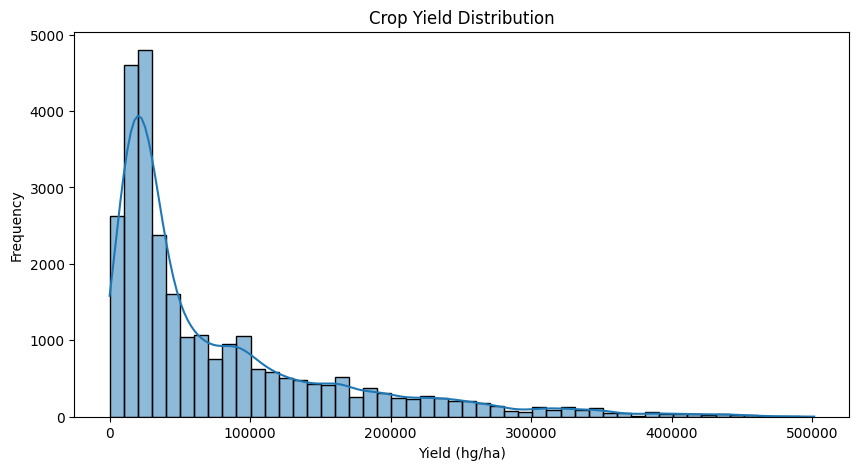

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["hg/ha_yield"],
    bins=50,
    kde=True
)

plt.title(
    "Crop Yield Distribution"
)

plt.xlabel(
    "Yield (hg/ha)"
)

plt.ylabel(
    "Frequency"
)

plt.show()

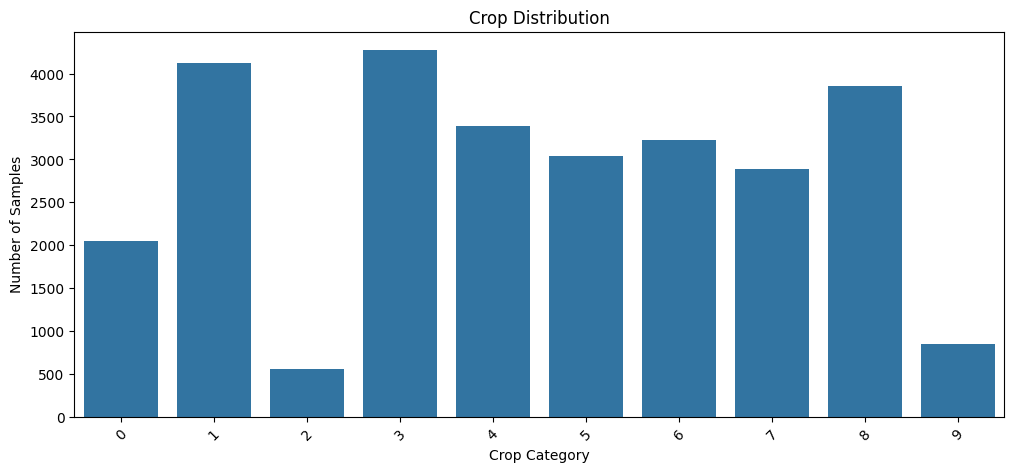

In [34]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="Item",
    data=df
)

plt.title(
    "Crop Distribution"
)

plt.xlabel(
    "Crop Category"
)

plt.ylabel(
    "Number of Samples"
)

plt.xticks(rotation=45)

plt.show()

In [35]:
raw_df = pd.read_csv(
    "../data/raw/crop_yield_raw.csv"
)

raw_df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


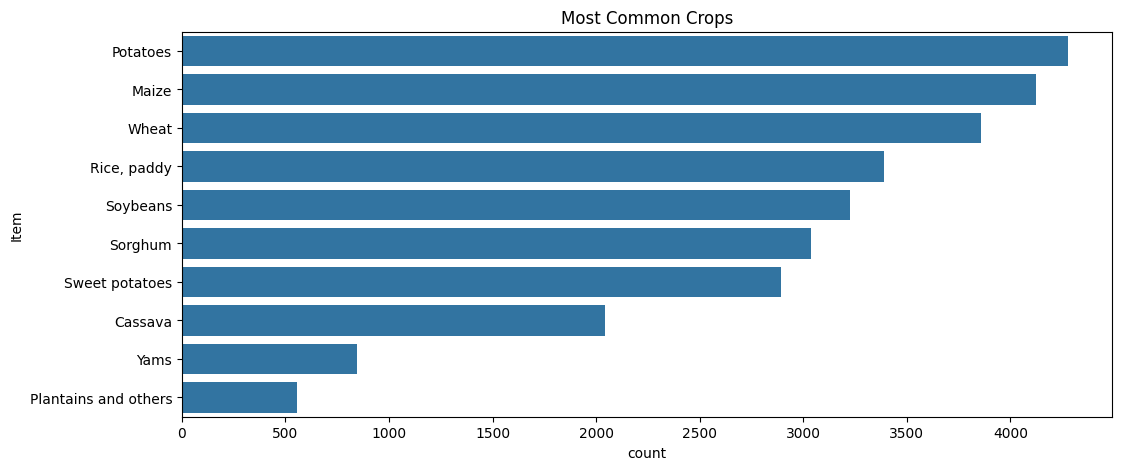

In [36]:
plt.figure(figsize=(12,5))

sns.countplot(
    y="Item",
    data=raw_df,
    order=raw_df["Item"].value_counts().index
)

plt.title(
    "Most Common Crops"
)

plt.show()

In [37]:
crop_yield = raw_df.groupby(
    "Item"
)["hg/ha_yield"].mean().sort_values(ascending=False)


crop_yield

Item
Potatoes                199801.549579
Cassava                 150479.466993
Sweet potatoes          119057.793772
Yams                    114140.345927
Plantains and others    106041.320144
Rice, paddy              40730.434770
Maize                    36310.070614
Wheat                    30116.267825
Sorghum                  18635.777229
Soybeans                 16731.092771
Name: hg/ha_yield, dtype: float64

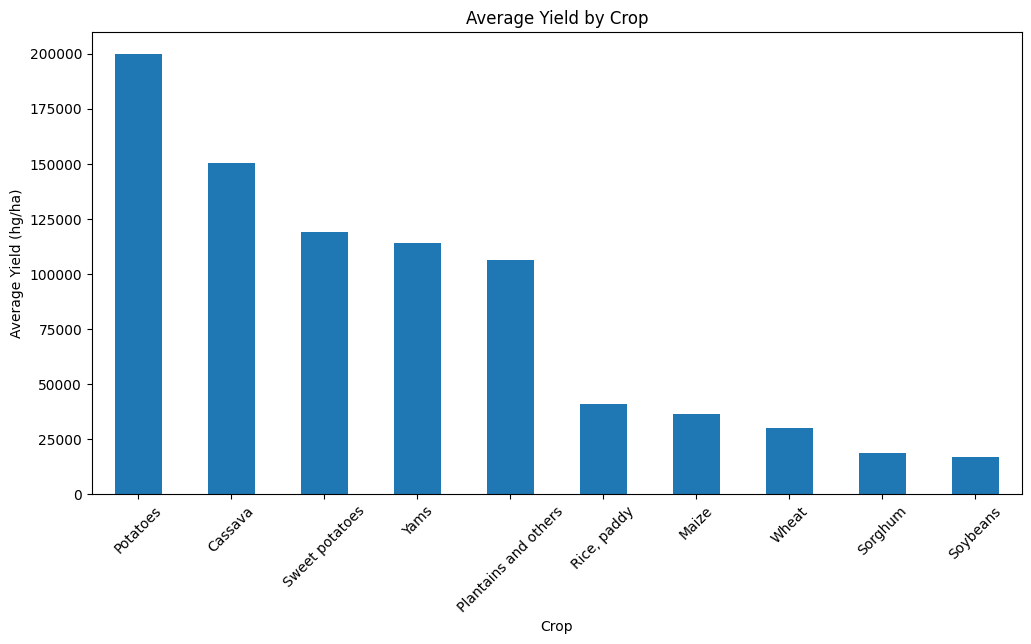

In [38]:
plt.figure(figsize=(12,6))

crop_yield.plot(
    kind="bar"
)

plt.title(
    "Average Yield by Crop"
)

plt.xlabel(
    "Crop"
)

plt.ylabel(
    "Average Yield (hg/ha)"
)

plt.xticks(rotation=45)

plt.show()

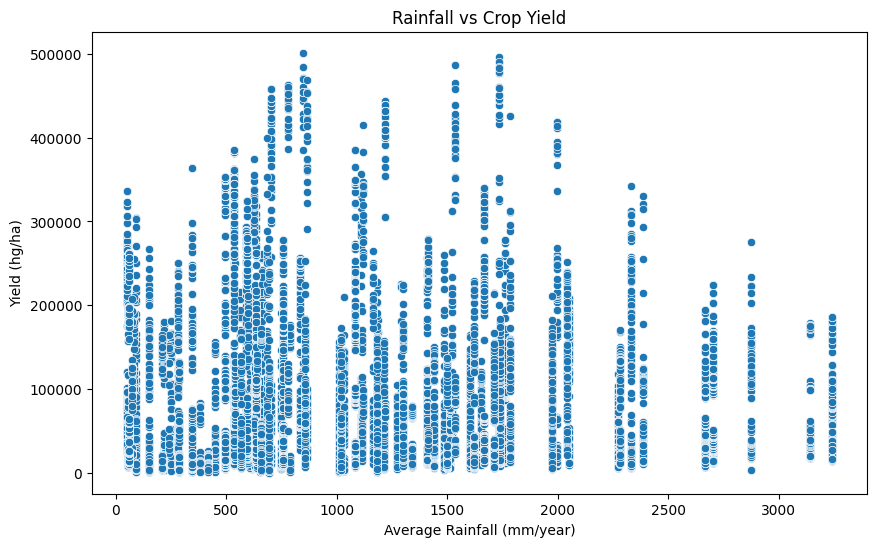

In [39]:
plt.figure(figsize=(10,6))


sns.scatterplot(
    data=df,
    x="average_rain_fall_mm_per_year",
    y="hg/ha_yield"
)


plt.title(
    "Rainfall vs Crop Yield"
)


plt.xlabel(
    "Average Rainfall (mm/year)"
)


plt.ylabel(
    "Yield (hg/ha)"
)


plt.show()

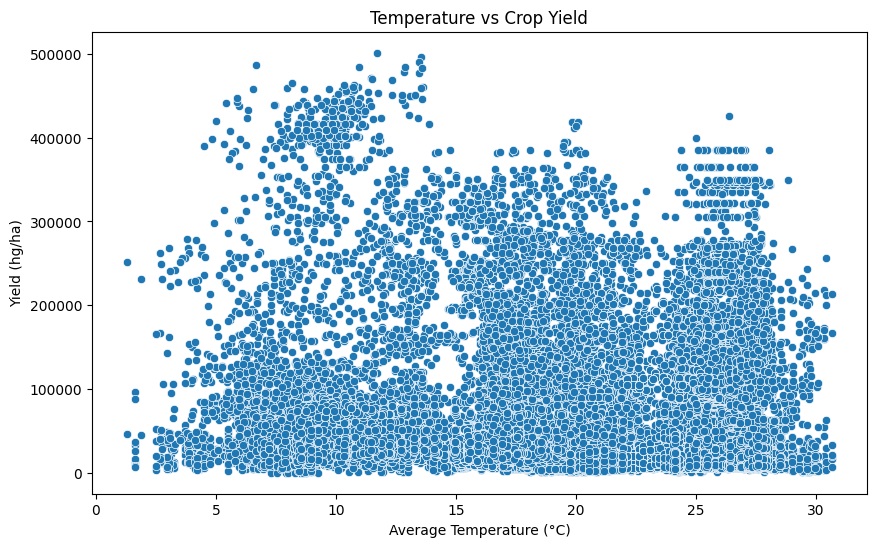

In [40]:
plt.figure(figsize=(10,6))


sns.scatterplot(
    data=df,
    x="avg_temp",
    y="hg/ha_yield"
)


plt.title(
    "Temperature vs Crop Yield"
)


plt.xlabel(
    "Average Temperature (°C)"
)


plt.ylabel(
    "Yield (hg/ha)"
)


plt.show()

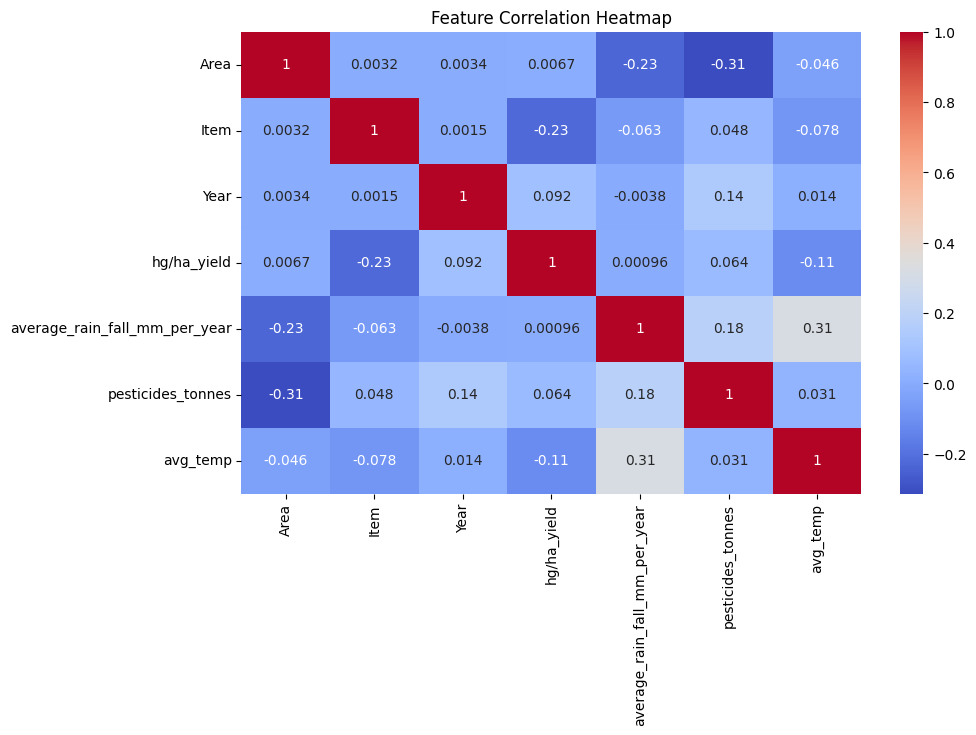

In [41]:
plt.figure(figsize=(10,6))


correlation = df.corr()


sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)


plt.title(
    "Feature Correlation Heatmap"
)


plt.show()